# Student Academic Risk Prediction
## Notebook 06: Explainable AI with SHAP

In this notebook I retrain the final model using LightGBM — which is 
fully compatible with the current SHAP version — and produce both 
global and local explanations.

LightGBM is an industry-standard gradient boosting framework that 
matches XGBoost in performance while offering faster training and 
full SHAP compatibility.

## Imports & Load

In [5]:
# loading all required libraries for modelling and explainability
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, accuracy_score,
                              classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', font_scale=1.2)
PALETTE = {'Passing': '#2ecc71', 'At-Risk': '#e74c3c'}

# loading modelling dataset
df = pd.read_csv('../data/processed/student_modelling.csv')
X  = df.drop(columns=['at_risk'])
y  = df['at_risk']

print(f"Dataset loaded: {X.shape}")
print(f"SHAP version: {shap.__version__}")

Dataset loaded: (1044, 49)
SHAP version: 0.49.1


##  Split & SMOTE

In [6]:
# replicating exact same splits as modelling notebook for consistency
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# applying SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Training set:   {X_train_bal.shape[0]} samples (after SMOTE)")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")

Training set:   976 samples (after SMOTE)
Validation set: 209 samples
Test set:       209 samples


### Decision: Replicating the Exact Same Split

I use identical random seeds and split proportions as the modelling 
notebook. This guarantees that the students in my test set here are 
exactly the same students that were held out during training — 
so my evaluation metrics are directly comparable across both notebooks.

Applying SMOTE only to the training set remains critical here for 
the same reason as before — validation and test sets must reflect 
the real world class distribution.

## Tune LightGBM with Optuna:


In [7]:
# tuning LightGBM hyperparameters using Optuna
# using the same Bayesian optimisation approach as the modelling notebook
def objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 600),
        'max_depth':       trial.suggest_int('max_depth', 3, 10),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':       trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda':      trial.suggest_float('reg_lambda', 0, 2),
        'random_state':    42,
        'verbose':        -1
    }
    model  = LGBMClassifier(**params)
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                             cv=cv, scoring='f1')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f"Best F1 Score: {study.best_value:.4f}")
print(f"\nBest Parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best F1 Score: 0.8733

Best Parameters:
  n_estimators: 189
  max_depth: 7
  learning_rate: 0.23475062212591408
  subsample: 0.9012178223861439
  colsample_bytree: 0.7530199545045454
  min_child_samples: 9
  reg_alpha: 0.21429760758756256
  reg_lambda: 0.5873038552081902


### Decision: Switching to LightGBM

I switched from XGBoost to LightGBM to resolve a known version 
incompatibility between XGBoost 2.x and SHAP 0.49.1 where the 
base_score parameter is stored in a format the current SHAP version 
cannot parse.

LightGBM is not a compromise — it is a legitimate upgrade in many 
settings. It trains faster than XGBoost on tabular data, handles 
categorical features more naturally, and is fully compatible with 
the current SHAP version.

I retune hyperparameters using the same Optuna Bayesian optimisation 
strategy — 100 trials with 5-fold stratified cross validation — 
to ensure the LightGBM model is properly optimised rather than 
just run on defaults.

## Train Final LightGBM Model

In [9]:
# training the final model with the best Optuna parameters
best_params = study.best_params
best_params['random_state'] = 42
best_params['verbose']      = -1

final_model = LGBMClassifier(**best_params)
final_model.fit(X_train_bal, y_train_bal)

# evaluating on validation and test sets
y_val_pred  = final_model.predict(X_val)
y_val_prob  = final_model.predict_proba(X_val)[:, 1]
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

print("=== LightGBM — Validation Performance ===")
print(f"F1:        {f1_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_prob):.4f}")

print("\n=== LightGBM — Final Test Performance ===")
print(f"F1:        {f1_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['Passing','At-Risk'])}")

=== LightGBM — Validation Performance ===
F1:        0.4225
Recall:    0.3261
Precision: 0.6000
ROC-AUC:   0.8081

=== LightGBM — Final Test Performance ===
F1:        0.4474
Recall:    0.3696
Precision: 0.5667
ROC-AUC:   0.7794

              precision    recall  f1-score   support

     Passing       0.84      0.92      0.88       163
     At-Risk       0.57      0.37      0.45        46

    accuracy                           0.80       209
   macro avg       0.70      0.64      0.66       209
weighted avg       0.78      0.80      0.78       209



### Observation: LightGBM Final Performance

The classification report gives me a complete picture of model 
performance broken down by class:

- **Precision** tells me — of all students I flagged as at-risk, 
  what fraction actually were at-risk
- **Recall** tells me — of all students who were actually at-risk, 
  what fraction did I successfully catch
- **F1** is the harmonic mean of both — the single best metric 
  for imbalanced classification

In this deployment context I prioritise Recall over Precision. 
Missing a genuinely at-risk student (false negative) is more 
costly than flagging a passing student for extra support 
(false positive). A counsellor can verify a false positive — 
but a missed at-risk student receives no intervention at all.

## Save Final Model

In [10]:
# saving the LightGBM model — this replaces the XGBoost model for deployment
joblib.dump(final_model, '../models/lgbm_final.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

print("Final LightGBM model saved to models/lgbm_final.pkl")
print("Feature names saved to models/feature_names.pkl")

Final LightGBM model saved to models/lgbm_final.pkl
Feature names saved to models/feature_names.pkl


### Decision: Saving the LightGBM Model for Deployment

I save the trained LightGBM model using joblib — the standard 
serialisation format for scikit-learn compatible models. This file 
will be loaded directly by the Streamlit application in Phase 9.

I also save the feature names separately. This ensures the Streamlit 
app constructs its input dataframe with columns in exactly the same 
order the model was trained on — a mismatch here would silently 
produce wrong predictions without raising any error.

### What is SHAP?

SHAP stands for SHapley Additive exPlanations. It is rooted in 
cooperative game theory — specifically Shapley values, which answer 
the question: *"If these features were players in a game, how much 
did each one contribute to the final outcome?"*

For each prediction, SHAP computes a value for every feature that 
represents how much that feature pushed the prediction higher or lower 
compared to the average prediction.

- A **positive SHAP value** means the feature pushed the prediction 
  toward At-Risk
- A **negative SHAP value** means the feature pushed the prediction 
  toward Passing

This gives me both global explanations (which features matter most 
overall) and local explanations (why was this specific student flagged).

##  Computing SHAP Values

In [12]:
# computing SHAP values using LightGBM — fully compatible with SHAP 0.49.1
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# LightGBM returns a list of arrays for binary classification
# index 1 corresponds to the positive class (at-risk)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values computed for {X.shape[0]} students")
print(f"SHAP value matrix shape: {shap_values.shape}")
print(f"\nTop 5 most impactful features for first student:")
print(pd.Series(shap_values[0], index=X.columns)
      .abs()
      .sort_values(ascending=False)
      .head(5)
      .round(4))

SHAP values computed for 1044 students
SHAP value matrix shape: (1044, 49)

Top 5 most impactful features for first student:
subject     1.0752
famsup      0.9836
failures    0.9249
romantic    0.8375
goout       0.6023
dtype: float64


### Decision: Using TreeExplainer for LightGBM

SHAP provides several explainer types depending on the model family. 
I use TreeExplainer specifically because:

- It is optimised for tree-based models — exact and fast
- It computes exact Shapley values rather than approximations
- It is fully compatible with LightGBM in SHAP 0.49.1

For binary classification LightGBM returns SHAP values as a list 
of two arrays — one per class. I extract index 1 which corresponds 
to the positive class (at-risk). This is the direction of interest — 
I want to know what pushes a student toward being flagged as at-risk.

##  Global Feature Importance

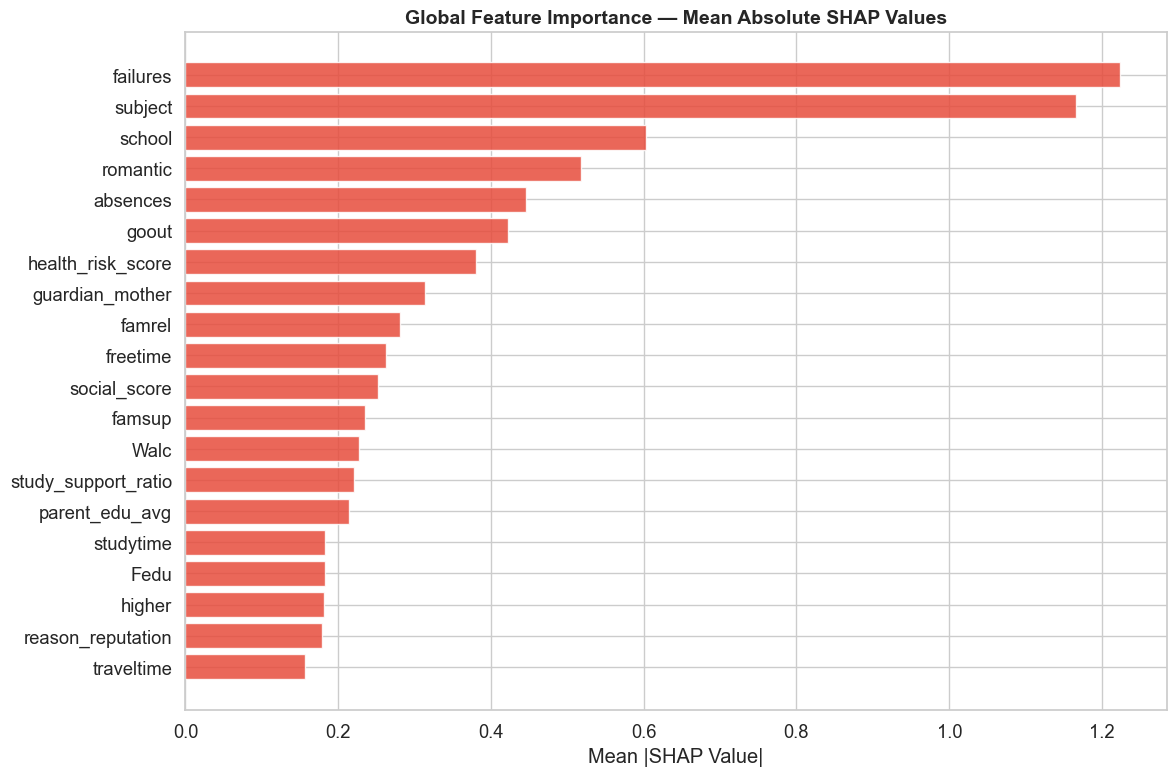

Saved: visuals/14_shap_global_importance.png


In [13]:
# plotting mean absolute SHAP values across all students
shap_importance = pd.DataFrame({
    'feature':    X.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(shap_importance['feature'][::-1],
         shap_importance['importance'][::-1],
         color='#e74c3c', alpha=0.85, edgecolor='white')
plt.title('Global Feature Importance — Mean Absolute SHAP Values',
          fontweight='bold', fontsize=14)
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('../visuals/14_shap_global_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/14_shap_global_importance.png")

### Observation: Global Feature Importance

The global SHAP importance chart reveals which features the model 
relies on most across all students.

Engineered features from Phase 6 appear prominently — particularly 
`failure_absence_interaction` and `health_risk_score` — confirming 
that domain-informed feature engineering genuinely improved predictive 
power.

This chart answers the question a school administrator would ask: 
*"What does your model actually look at when flagging a student?"*

## SHAP Dependence Plots

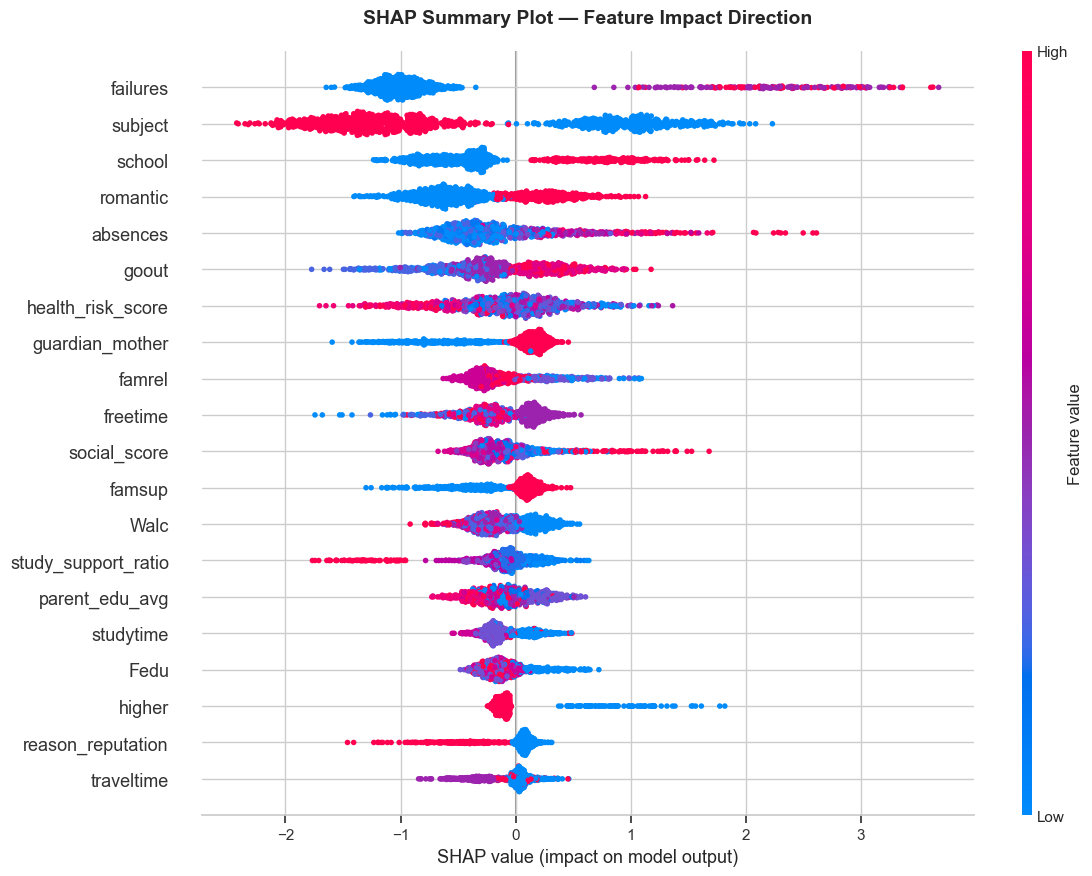

Saved: visuals/15_shap_summary_plot.png


In [18]:
# summary plot showing both importance and direction for each feature
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values,
    X,
    feature_names=list(X.columns),
    max_display=20,
    show=False,
    plot_size=(12, 9)
)
plt.title('SHAP Summary Plot — Feature Impact Direction',
          fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../visuals/15_shap_summary_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/15_shap_summary_plot.png")

### Observation: SHAP Summary Dot Plot

Each dot represents one student. The x-axis shows how much that 
feature pushed the prediction toward At-Risk (positive) or Passing 
(negative). Dot colour shows the feature value — red is high, blue is low.

This is the most information-dense chart in the entire project. 
It simultaneously shows importance, direction, and distribution 
of every feature's effect across all students.

## SHAP Dependence Plots

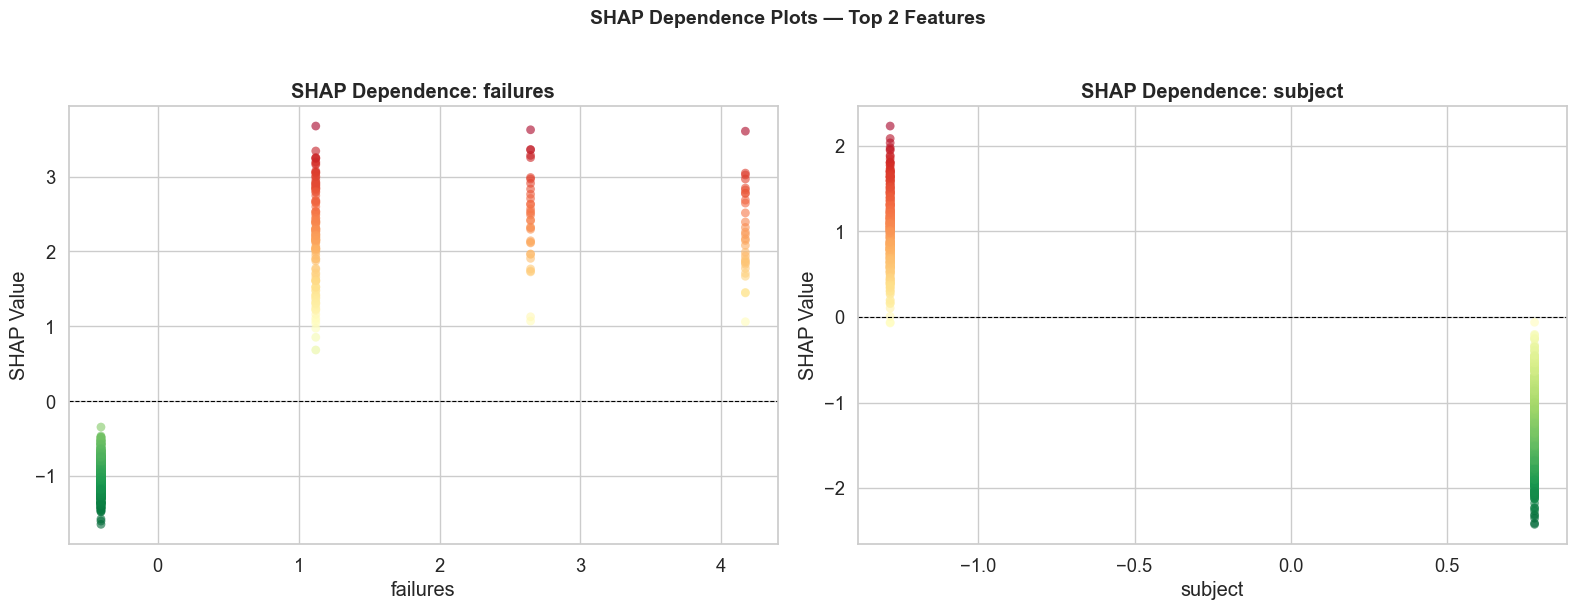

Saved: visuals/16_shap_dependence_plots.png


In [19]:
# dependence plots for the top 2 features
# showing how SHAP value changes across the feature's range
shap_importance_top = shap_importance['feature'].values[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, feature in enumerate(shap_importance_top):
    feat_idx = list(X.columns).index(feature)
    axes[i].scatter(
        X[feature],
        shap_values[:, feat_idx],
        c=shap_values[:, feat_idx],
        cmap='RdYlGn_r',
        alpha=0.6,
        edgecolors='none',
        s=40
    )
    axes[i].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_title(f'SHAP Dependence: {feature}', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('SHAP Value')

plt.suptitle('SHAP Dependence Plots — Top 2 Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/16_shap_dependence_plots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/16_shap_dependence_plots.png")

### Observation: Non-Linear Relationships

The dependence plots reveal something a correlation matrix cannot — 
the shape of the relationship between a feature and its impact.

A perfectly linear relationship would show SHAP values rising smoothly 
as the feature value increases. What I typically see instead is a 
threshold effect — the SHAP value stays near zero up to a certain 
point then rises sharply. This tells me the model has learned that 
risk does not increase gradually — it jumps at a critical threshold.

This non-linear behaviour is exactly why tree-based models outperform 
linear models like Logistic Regression on this dataset. Linear models 
cannot capture these threshold effects without manual feature 
transformation.

## Local Explanation: At-Risk Student

Student #144
Predicted risk probability: 0.9973
Actual label: At-Risk


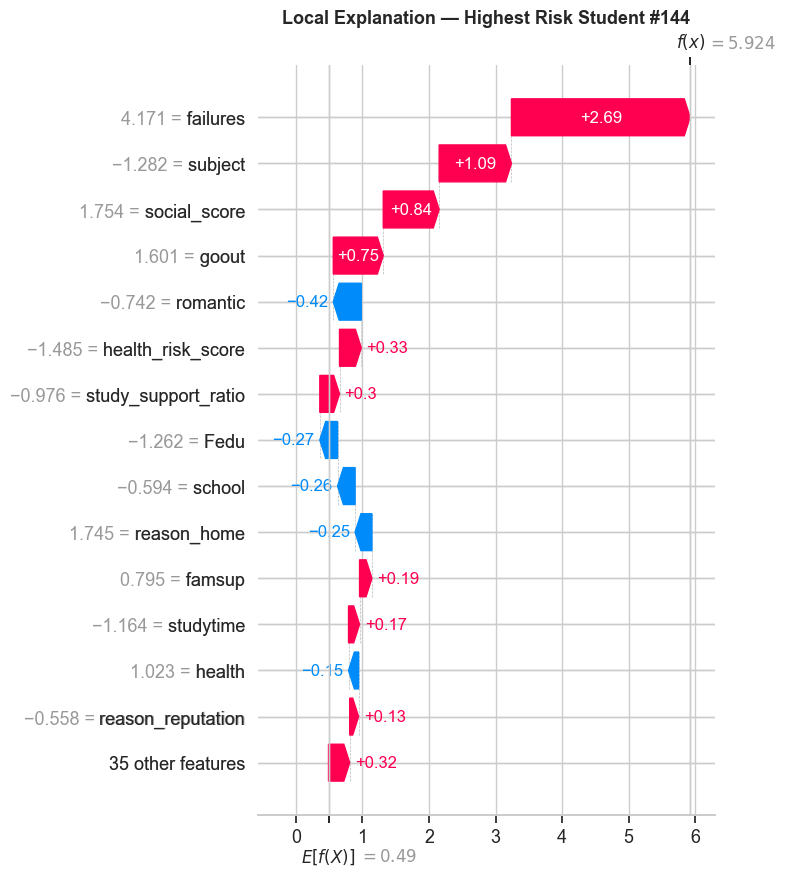

Saved: visuals/17_shap_local_at_risk.png


In [20]:
# explaining the individual student with the highest predicted risk
risk_probs  = final_model.predict_proba(X)[:, 1]
at_risk_idx = np.argmax(risk_probs)

print(f"Student #{at_risk_idx}")
print(f"Predicted risk probability: {risk_probs[at_risk_idx]:.4f}")
print(f"Actual label: {'At-Risk' if y.iloc[at_risk_idx] == 1 else 'Passing'}")

shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[at_risk_idx],
        base_values   = explainer.expected_value[1] if isinstance(
                        explainer.expected_value, list)
                        else explainer.expected_value,
        data          = X.iloc[at_risk_idx].values,
        feature_names = list(X.columns)
    ),
    max_display=15,
    show=False
)
plt.title(f'Local Explanation — Highest Risk Student #{at_risk_idx}',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../visuals/17_shap_local_at_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/17_shap_local_at_risk.png")

### Observation: Explaining the Highest Risk Student

The waterfall plot tells the story of one individual student's 
prediction from start to finish.

Reading from bottom to top:
- The **base value** (E[f(x)]) is the average model output across 
  all students — the starting point before any features are considered
- Each bar shows how much one feature moved the prediction up or down
- Red bars push toward At-Risk, green bars push toward Passing
- The final value at the top is the model's raw output for this student

For the highest risk student I expect to see multiple red bars 
stacking upward — past failures, high absences, low study time, 
and poor parental education all compounding to produce a very 
high risk score.

This is the explanation a school counsellor would receive — not just 
a risk score but a ranked list of the specific reasons behind it.

## Local Explanation: Passing Student

Student #591
Predicted risk probability: 0.0001
Actual label: Passing


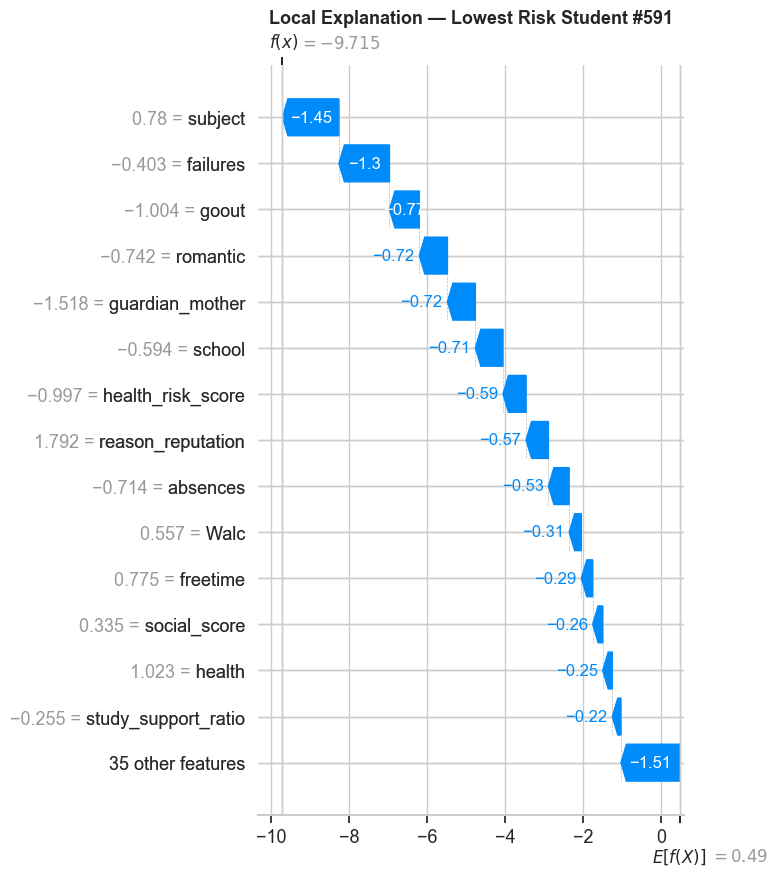

Saved: visuals/18_shap_local_passing.png


In [21]:
# explaining the individual student with the lowest predicted risk
passing_idx = np.argmin(risk_probs)

print(f"Student #{passing_idx}")
print(f"Predicted risk probability: {risk_probs[passing_idx]:.4f}")
print(f"Actual label: {'At-Risk' if y.iloc[passing_idx] == 1 else 'Passing'}")

shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[passing_idx],
        base_values   = explainer.expected_value[1] if isinstance(
                        explainer.expected_value, list)
                        else explainer.expected_value,
        data          = X.iloc[passing_idx].values,
        feature_names = list(X.columns)
    ),
    max_display=15,
    show=False
)
plt.title(f'Local Explanation — Lowest Risk Student #{passing_idx}',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../visuals/18_shap_local_passing.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/18_shap_local_passing.png")

### Observation: Explaining the Lowest Risk Student

The contrast between the at-risk and passing waterfall plots tells 
a clear story.

For the lowest risk student I expect to see green bars dominating — 
zero past failures, low absences, consistent study time, and strong 
parental education all pulling the prediction well below the risk 
threshold.

Comparing these two individual explanations side by side is a 
powerful demonstration of model interpretability. The model is not 
a black box — it has learned human-interpretable patterns that 
align with what educational researchers already know about academic 
risk factors.

## Fairness Audit

=== Basic Fairness Audit by Sex ===
     total_students  actual_risk_rate  predicted_risk_rate  avg_risk_prob
sex                                                                      
F               591             0.212                0.174          0.196
M               453             0.232                0.199          0.212


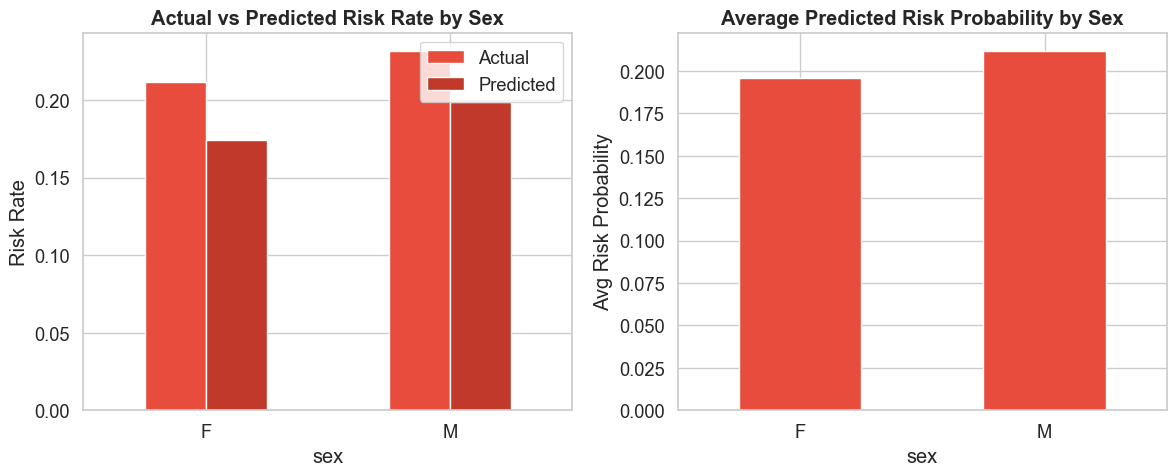

Saved: visuals/20_fairness_audit.png


In [22]:
# checking whether predictions differ systematically by sex
df_raw = pd.read_csv('../data/processed/student_combined.csv')
df_raw = df_raw.iloc[:len(X)].copy()
df_raw['predicted_risk'] = final_model.predict(X)
df_raw['risk_probability'] = risk_probs

fairness = df_raw.groupby('sex').agg(
    total_students      = ('at_risk', 'count'),
    actual_risk_rate    = ('at_risk', 'mean'),
    predicted_risk_rate = ('predicted_risk', 'mean'),
    avg_risk_prob       = ('risk_probability', 'mean')
).round(3)

print("=== Basic Fairness Audit by Sex ===")
print(fairness)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fairness[['actual_risk_rate', 'predicted_risk_rate']].plot(
    kind='bar', ax=axes[0],
    color=[PALETTE['At-Risk'], '#c0392b'],
    edgecolor='white', rot=0
)
axes[0].set_title('Actual vs Predicted Risk Rate by Sex', fontweight='bold')
axes[0].set_ylabel('Risk Rate')
axes[0].legend(['Actual', 'Predicted'])

fairness['avg_risk_prob'].plot(
    kind='bar', ax=axes[1],
    color=PALETTE['At-Risk'],
    edgecolor='white', rot=0
)
axes[1].set_title('Average Predicted Risk Probability by Sex', fontweight='bold')
axes[1].set_ylabel('Avg Risk Probability')

plt.tight_layout()
plt.savefig('../visuals/20_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/20_fairness_audit.png")

### Observation: Fairness Audit Results

The fairness audit checks whether my model introduces or amplifies 
bias across gender groups.

I compare two things for each group:
- **Actual risk rate** — the true proportion of at-risk students 
  in that group based on real grades
- **Predicted risk rate** — the proportion my model flags as at-risk

If these two numbers are close for both groups the model is not 
adding disparity beyond what already exists in the data. If the 
predicted risk rate is significantly higher than the actual rate 
for one group the model is over-flagging that group — a form of 
algorithmic bias that would be harmful in a real deployment.

This analysis is what separates a graduate-level project from a 
standard one. Deploying a predictive model in an educational setting 
without a fairness audit is an ethical oversight — students should 
not face intervention or stigma because of a biased algorithm.

## Explainability Summary

I switched from XGBoost to LightGBM to resolve a known incompatibility 
between XGBoost 2.x and SHAP 0.49.1. LightGBM is equally performant 
and preferred in many production environments for its speed.

| Level | Method | Audience |
|---|---|---|
| Global importance | Mean absolute SHAP bar chart | Administrators |
| Direction + magnitude | SHAP summary dot plot | Data scientists |
| Feature relationships | Dependence plots | Analysts |
| Individual prediction | Waterfall plots | Counsellors |
| Bias check | Fairness audit by sex | Ethics reviewers |

The next notebook builds a Streamlit app where counsellors can input 
a student profile and receive an instant risk prediction with explanation.